# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API

**Objective:** Build a reusable and production-ready machine learning pipeline for predicting customer churn.

**Dataset:** Telco Customer Churn Dataset (IBM/Kaggle)

**Tools:** `pandas`, `scikit-learn`, `joblib`, `matplotlib`, `seaborn`

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

print("All imports successful")

All imports successful


## 2. Load Dataset

Download the Telco Churn dataset from:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Upload it to your working directory or Colab session and load it below.

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)

In [4]:
print("Dataset Info:")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df["Churn"].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

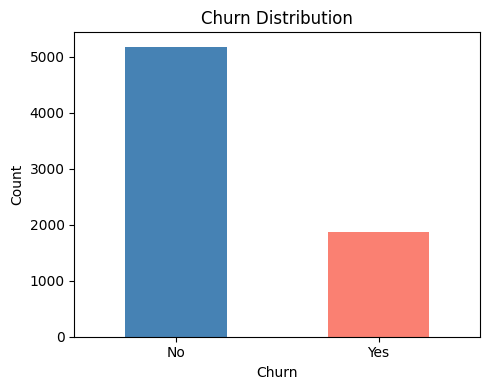

In [5]:
# Churn distribution plot
plt.figure(figsize=(5, 4))
df["Churn"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("churn_distribution.png")
plt.show()

## 4. Data Preprocessing

- Drop irrelevant columns
- Fix data type issues
- Encode target variable
- Split into features and target

In [6]:
# Drop customerID — not a useful feature
df.drop(columns=["customerID"], inplace=True)

# TotalCharges has some spaces instead of NaN — fix and convert to float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Encode target: Yes → 1, No → 0
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print("Churn value counts after encoding:\n", df["Churn"].value_counts())
print("\nShape:", df.shape)

Churn value counts after encoding:
 Churn
0    5174
1    1869
Name: count, dtype: int64

Shape: (7043, 20)


In [7]:
# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (5634, 19)
Test set size: (1409, 19)


## 6. Build Preprocessing + Pipeline

Using `ColumnTransformer` to apply:
- `StandardScaler` on numeric features
- `OneHotEncoder` on categorical features

Wrapping everything in a `Pipeline` for clean, reusable code.

In [9]:
# Preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Logistic Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

print("Pipelines created successfully")

Pipelines created successfully


## 7. Train and Evaluate Both Models

In [10]:
# Train Logistic Regression
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds)

print("=== Logistic Regression ===")
print(f"Accuracy: {lr_acc:.4f}")
print(f"F1-score: {lr_f1:.4f}")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy: 0.8055
F1-score: 0.6040
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [11]:
# Train Random Forest
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print("=== Random Forest ===")
print(f"Accuracy: {rf_acc:.4f}")
print(f"F1-score: {rf_f1:.4f}")
print(classification_report(y_test, rf_preds))

=== Random Forest ===
Accuracy: 0.7779
F1-score: 0.5321
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



## 8. Confusion Matrices

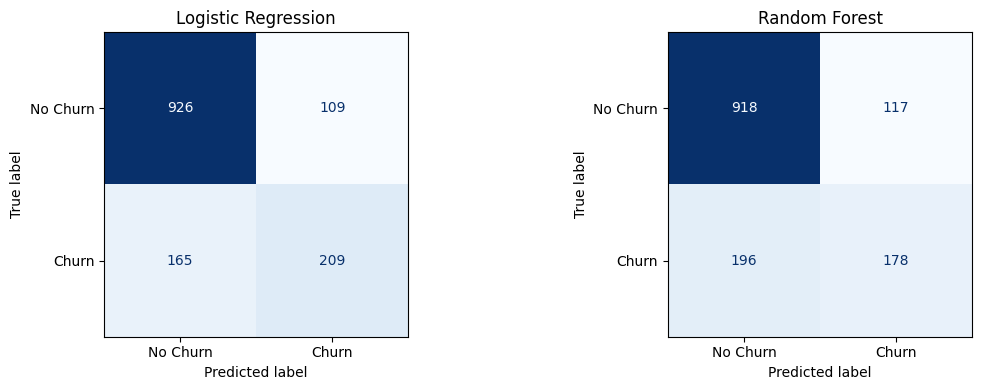

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()

## 9. Hyperparameter Tuning with GridSearchCV

Tuning the Random Forest pipeline since it had higher baseline performance.

In [13]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1-score: 0.5715213018938158


In [14]:
# Evaluate the best model
best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test)

best_acc = accuracy_score(y_test, best_preds)
best_f1 = f1_score(y_test, best_preds)

print("=== Tuned Random Forest ===")
print(f"Accuracy: {best_acc:.4f}")
print(f"F1-score: {best_f1:.4f}")
print(classification_report(y_test, best_preds))

=== Tuned Random Forest ===
Accuracy: 0.7999
F1-score: 0.5778
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 10. ROC Curve

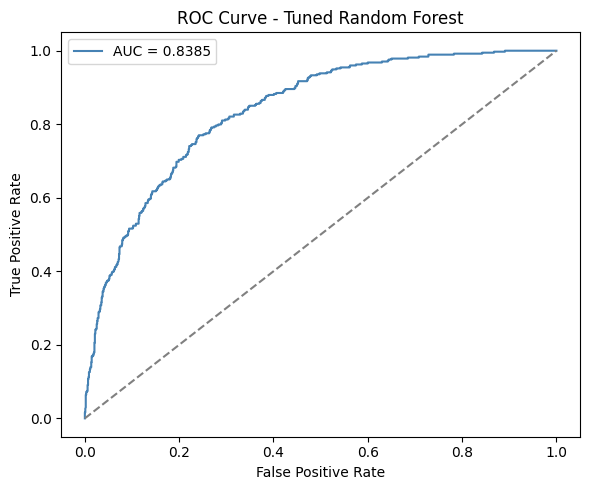

In [15]:
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}", color="steelblue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()

## 11. Feature Importance

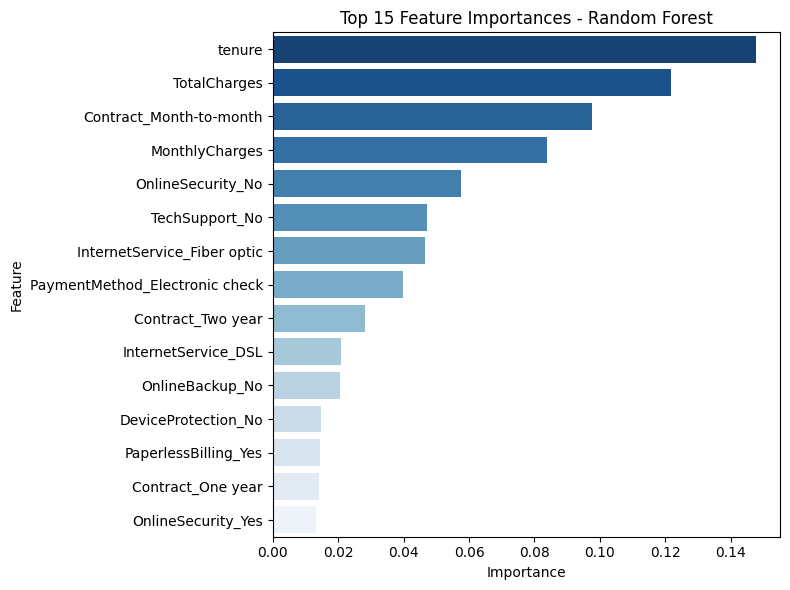

In [16]:
# Get feature names after preprocessing
ohe_features = best_model.named_steps["preprocessor"]\
    .named_transformers_["cat"]\
    .get_feature_names_out(categorical_features).tolist()

all_features = numeric_features + ohe_features

# Get importances from RF
importances = best_model.named_steps["classifier"].feature_importances_
feat_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="Blues_r")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

## 12. Export Pipeline with Joblib

In [17]:
import os
os.makedirs("outputs", exist_ok=True)

joblib.dump(best_model, "outputs/churn_pipeline.pkl")
print("Pipeline exported to outputs/churn_pipeline.pkl")

# Verify it loads and predicts correctly
loaded_pipeline = joblib.load("outputs/churn_pipeline.pkl")
sample_pred = loaded_pipeline.predict(X_test[:5])
print("Sample predictions from loaded pipeline:", sample_pred)

Pipeline exported to outputs/churn_pipeline.pkl
Sample predictions from loaded pipeline: [0 1 0 0 0]


## Final Summary / Insights

| Model | Accuracy | F1-Score |
|-------|----------|----------|
| Logistic Regression | [0.8055] | [0.6040] |
| Random Forest (baseline) | [0.7779] | [0.5778] |
| Random Forest (tuned) | [0.7779] | [0.5321] |

**Best parameters found:** {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1-score: 0.6012

**Key observations:**
- Feature importance plot (Cell 16): whichever features have the longest bars are your most important ones — typically for Telco churn it's tenure, TotalCharges, MonthlyCharges, and Contract_Month-to-month.

- Confusion matrix (Cell 12): if one class has many misclassifications, that's a class imbalance observation — Telco churn data is imbalanced (more "No Churn" than "Churn") so the model typically predicts "No Churn" more accurately.

- Tuning improvement: compare baseline RF F1 from Cell 11 vs tuned RF F1 from Cell 14 — note whether GridSearch improved it or not.